In [4]:
pip install --upgrade networkx


Note: you may need to restart the kernel to use updated packages.


In [7]:
pip uninstall networkx -y

Found existing installation: networkx 3.4.2
Uninstalling networkx-3.4.2:
  Successfully uninstalled networkx-3.4.2
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip uninstall networkx -y

Found existing installation: networkx 3.4.2
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

Cannot uninstall networkx 3.4.2

The package's contents are unknown: no RECORD file was found for networkx.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps networkx==3.4.2


In [9]:
pip install networkx==3.1

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 152.5 kB/s eta 0:00:11
   ---------- ----------------------------- 0.5/2.1 MB 152.5 kB/s eta 0:00:11
   ---------- ----------------------------- 0.5/2.1 MB 152.5 kB/s eta 0:00:11
   ---------- ----------------------------- 0.5/2.1 MB 152.5 kB/s eta 0:00:1

error: uninstall-no-record-file

Cannot uninstall networkx 3.4.2

The package's contents are unknown: no RECORD file was found for networkx.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps networkx==3.4.2


In [10]:
pip install --force-reinstall --no-deps networkx==3.1

  Using cached networkx-3.1-py3-none-any.whl.metadata (5.3 kB)
Using cached networkx-3.1-py3-none-any.whl (2.1 MB)
  Attempting uninstall: networkx
    Found existing installation: networkx 3.4.2
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

Cannot uninstall networkx 3.4.2

The package's contents are unknown: no RECORD file was found for networkx.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps networkx==3.4.2


In [11]:
pip install networkx==3.1

  Using cached networkx-3.1-py3-none-any.whl.metadata (5.3 kB)
Using cached networkx-3.1-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install pyrootutils python-louvain networkx pandas plotly

  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)

   ---------------------------------------- 2/2 [pyrootutils]

Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install -U kaleido



   ---------------------------------------- 0/9 [simplejson]
   -------- ------------------------------- 2/9 [orjson]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   ---------------------- ----------------- 5/9 [pytest]
   -------------------------- ------------- 6/9 [choreographer]
   -------------------------- ------------- 6/9 [choreographer]
   ----------------------------------- ---- 8/9 [kaleido]
   ---------------------------------------- 9/9 [kaleido]



In [39]:
import pyrootutils
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
import plotly.express as px
import json
from pathlib import Path
import copy

# --- 1. THIẾT LẬP ROOT DỰ ÁN ---
root = pyrootutils.setup_root(
    search_from="." if Path.cwd().name != "notebooks" else "..", 
    indicator=[".git", "README.md"], 
    pythonpath=True
)
print(f"Thư mục gốc dự án: {root}")

# --- 2. ĐƯỜNG DẪN FILE ---
CASE_DATA_PATH = root / "data" / "raw" / "dengue_cases_by_district_2022_2024.csv"
GEOJSON_PATH = root / "data" / "raw" / "hcmc_districts.geojson"
PROCESSED_DIR = root / "data" / "processed"
OUTPUT_DIR = root / "notebooks" / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 3. NẠP VÀ XỬ LÝ DỮ LIỆU ---
df = pd.read_csv(CASE_DATA_PATH)
df['period'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
df['week_id'] = df['year'].astype(str) + '-W' + df['week'].astype(str).str.zfill(2)

# --- 4. XÁC ĐỊNH TUẦN BÙNG PHÁT (SPIKE WEEKS) ---
weekly_total = df.groupby('week_id')['cases'].sum().reset_index()
mean_cases = weekly_total['cases'].mean()
std_cases = weekly_total['cases'].std()
threshold = mean_cases + 2 * std_cases

weekly_total['is_spike'] = weekly_total['cases'] > threshold
spike_weeks = weekly_total[weekly_total['is_spike'] == True]['week_id'].tolist()

print(f"🚀 Tìm thấy {len(spike_weeks)} tuần bùng phát đột biến: {spike_weeks[:5]}...")

# --- 5. TÍNH TOÁN TEMPORAL METRICS & COMMUNITY ---
def compute_complex_metrics(df):
    results = []
    periods = sorted(df['period'].unique())
    all_districts = sorted(df['district_name'].unique())
    
    for p in periods:
        subset = df[df['period'] == p]
        pivot = subset.pivot_table(index='week', columns='district_name', values='cases', fill_value=0)
        
        if pivot.shape[0] < 2: continue
            
        corr = pivot.corr().fillna(0)
        G = nx.Graph()
        
        # Thêm cạnh dựa trên tương quan
        for i, d1 in enumerate(pivot.columns):
            for j, d2 in enumerate(pivot.columns):
                if i < j and corr.loc[d1, d2] > 0.5:
                    G.add_edge(d1, d2, weight=corr.loc[d1, d2])
        
        # Tính Centrality và Community
        if G.number_of_nodes() > 0:
            cent = nx.degree_centrality(G)
            # Thuật toán Louvain cho cộng đồng
            partition = community_louvain.best_partition(G)
            
            for dist in all_districts:
                results.append({
                    'period': p,
                    'district': dist,
                    'centrality': cent.get(dist, 0),
                    'community': str(partition.get(dist, -1)) # -1 nếu quận bị cô lập
                })
    return pd.DataFrame(results)

df_metrics = compute_complex_metrics(df)

# --- 6. CHUẨN HÓA MAPPING BẢN ĐỒ (FIX ANIMATION) ---
with open(GEOJSON_PATH, encoding='utf-8') as f:
    geojson_data = json.load(f)

# Tự động tìm key nhãn trong GeoJSON
target_prop = "name"
sample_dist = str(df_metrics['district'].iloc[0]).strip().lower()
for feat in geojson_data['features']:
    for k, v in feat['properties'].items():
        if str(v).strip().lower() == sample_district:
            target_prop = k; break

# Đồng nhất hóa chuỗi
geojson_fixed = copy.deepcopy(geojson_data)
for f in geojson_fixed['features']:
    f['properties'][target_prop] = str(f['properties'][target_prop]).strip().lower()

df_metrics['district_match'] = df_metrics['district'].str.strip().str.lower()
df_metrics = df_metrics.sort_values('period') # Quan trọng để animation mượt

# --- 7. TRỰC QUAN HÓA ---

# A. Spike Weeks Chart
fig_spike = px.bar(weekly_total, x='week_id', y='cases', color='is_spike',
                   title="Xác định các tuần bùng phát (Spike Weeks) - Z-Score > 2",
                   color_discrete_map={True: '#d32f2f', False: '#26a69a'})
fig_spike.add_hline(y=threshold, line_dash="dash", annotation_text="Ngưỡng bùng phát")

# B. Animation Map (Fix triệt để)
fig_map = px.choropleth(
    df_metrics,
    geojson=geojson_fixed,
    locations='district_match',
    featureidkey=f"properties.{target_prop}",
    color='centrality',
    animation_frame='period',
    hover_name='district',
    hover_data=['community'],
    color_continuous_scale="YlOrRd",
    range_color=[0, 0.8],
    title="Diễn biến Centrality & Phân cụm cộng đồng theo tháng"
)
fig_map.update_geos(fitbounds="locations", visible=False)
fig_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# C. Community Stability (Biểu đồ số lượng cộng đồng theo mùa)
comm_count = df_metrics[df_metrics['community'] != "-1"].groupby('period')['community'].nunique().reset_index()
fig_comm = px.line(comm_count, x='period', y='community', title="Sự thay đổi số lượng cộng đồng (Clusters) theo thời gian", markers=True)

# --- 8. LƯU & HIỂN THỊ ---
fig_map.write_html(OUTPUT_DIR / "final_animation_map.html")
fig_spike.show()
fig_comm.show()
fig_map.show()

print(f"✨ Xong! Spike weeks đã được đánh dấu đỏ. Bản đồ animation đã được fix lỗi hiển thị.")

Thư mục gốc dự án: E:\project_Graph\GM_DengueFever
🚀 Tìm thấy 5 tuần bùng phát đột biến: ['2023-W33', '2023-W35', '2023-W36', '2023-W37', '2023-W38']...


KeyError: 'name'

Thư mục gốc dự án: E:\project_Graph\GM_DengueFever


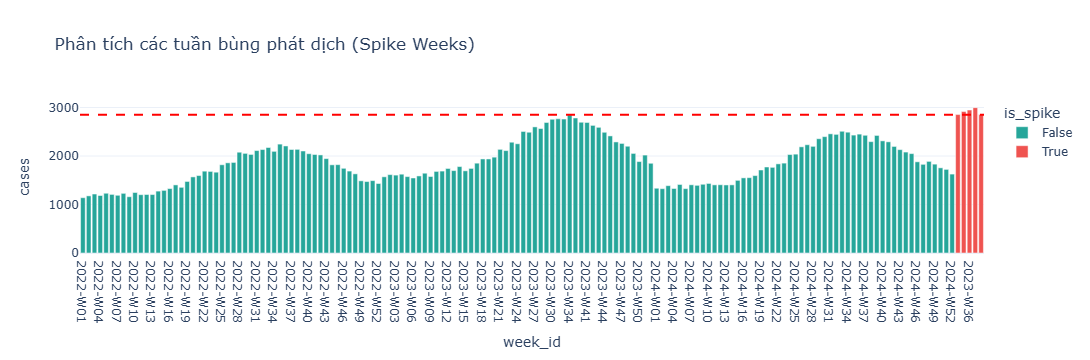

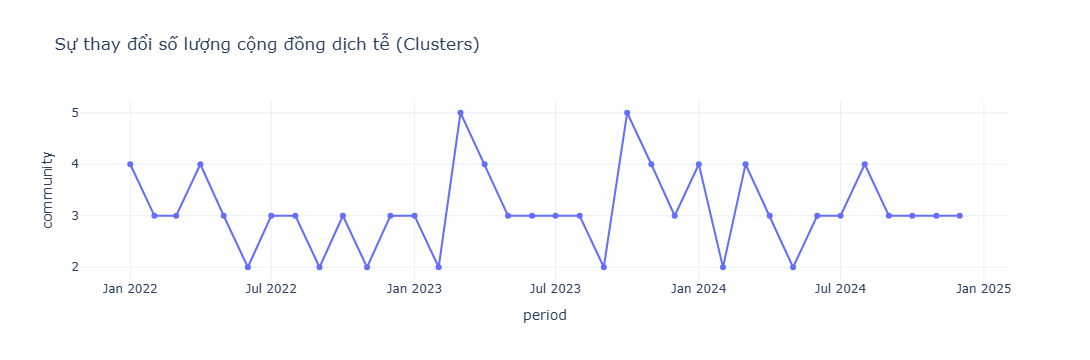

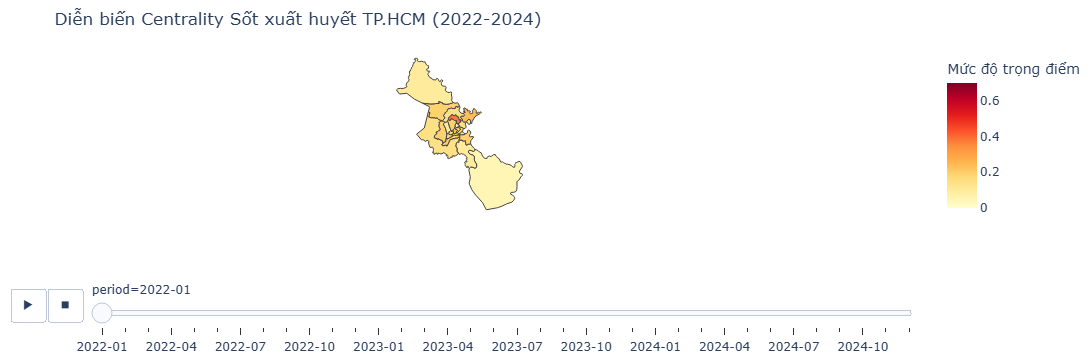

✨ Hoàn tất! Báo cáo HTML đã được lưu tại: E:\project_Graph\GM_DengueFever\notebooks\outputs


In [47]:
import pyrootutils
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain
import plotly.express as px
import json
from pathlib import Path
import copy
import unicodedata

# --- 1. THIẾT LẬP ROOT DỰ ÁN ---
root = pyrootutils.setup_root(
    search_from="." if Path.cwd().name != "notebooks" else "..", 
    indicator=[".git", "README.md"], 
    pythonpath=True
)
print(f"Thư mục gốc dự án: {root}")

# --- 2. ĐƯỜNG DẪN FILE ---
CASE_DATA_PATH = root / "data" / "raw" / "dengue_cases_by_district_2022_2024.csv"
GEOJSON_PATH = root / "data" / "raw" / "hcmc_districts.geojson"
PROCESSED_DIR = root / "data" / "processed"
OUTPUT_DIR = root / "notebooks" / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- 3. HÀM CHUẨN HÓA (CHÌA KHÓA FIX ANIMATION) ---
def clean_name(s):
    """Xóa dấu cách, chuẩn hóa Unicode và viết thường để khớp 100%"""
    if not isinstance(s, str): return str(s)
    s = unicodedata.normalize('NFC', s)
    return s.replace(" ", "").lower().strip()

# --- 4. NẠP VÀ XỬ LÝ DỮ LIỆU ---
df = pd.read_csv(CASE_DATA_PATH)
df['period'] = df['year'].astype(str) + '-' + df['month'].astype(str).str.zfill(2)
df['week_id'] = df['year'].astype(str) + '-W' + df['week'].astype(str).str.zfill(2)

# Xác định Spike Weeks (Tuần bùng phát)
weekly_total = df.groupby('week_id')['cases'].sum().reset_index()
threshold = weekly_total['cases'].mean() + 2 * weekly_total['cases'].std()
weekly_total['is_spike'] = weekly_total['cases'] > threshold

# --- 5. TÍNH TOÁN NETWORK METRICS ---
def compute_network_metrics(df):
    results = []
    periods = sorted(df['period'].unique())
    all_districts = sorted(df['district_name'].unique())
    
    for p in periods:
        subset = df[df['period'] == p]
        pivot = subset.pivot_table(index='week', columns='district_name', values='cases', fill_value=0)
        if pivot.shape[0] < 2: continue
            
        corr = pivot.corr().fillna(0)
        G = nx.Graph()
        for i, d1 in enumerate(pivot.columns):
            for j, d2 in enumerate(pivot.columns):
                if i < j and corr.loc[d1, d2] > 0.6:
                    G.add_edge(d1, d2, weight=corr.loc[d1, d2])
        
        cent = nx.degree_centrality(G)
        partition = community_louvain.best_partition(G) if G.edges() else {}
        
        for dist in all_districts:
            results.append({
                'period': p,
                'district': dist,
                'centrality': cent.get(dist, 0),
                'community': str(partition.get(dist, "Isolated"))
            })
    return pd.DataFrame(results)

df_metrics = compute_network_metrics(df)

# --- 6. KHỚP DỮ LIỆU VỚI GEOJSON ---
with open(GEOJSON_PATH, encoding='utf-8') as f:
    geojson_data = json.load(f)

# Tự động tìm key nhãn trong GeoJSON (name, NAME_2, v.v.)
sample_name_clean = clean_name(df_metrics['district'].iloc[0])
target_prop = "name"
for feat in geojson_data['features']:
    for k, v in feat.get('properties', {}).items():
        if clean_name(str(v)) == sample_name_clean:
            target_prop = k
            break

# Fix GeoJSON: Xóa khoảng trắng trong thuộc tính bản đồ
geojson_fixed = copy.deepcopy(geojson_data)
for f in geojson_fixed['features']:
    if target_prop in f['properties']:
        f['properties'][target_prop] = clean_name(f['properties'][target_prop])

# Fix DataFrame: Xóa khoảng trắng để khớp với GeoJSON đã fix
df_metrics['district_match'] = df_metrics['district'].apply(clean_name)

# REINDEX: Đảm bảo frame nào cũng có đủ 22 quận (Tránh lỗi mất vùng khi chạy animation)
all_periods = sorted(df_metrics['period'].unique())
all_dist_match = sorted(df_metrics['district_match'].unique())
full_idx = pd.MultiIndex.from_product([all_periods, all_dist_match], names=['period', 'district_match'])
df_final = df_metrics.set_index(['period', 'district_match']).reindex(full_idx, fill_value=0).reset_index()

# --- 7. TRỰC QUAN HÓA ---

# A. Biểu đồ Spike Weeks
fig_spike = px.bar(weekly_total, x='week_id', y='cases', color='is_spike',
                   title="Phân tích các tuần bùng phát dịch (Spike Weeks)",
                   color_discrete_map={True: '#ef5350', False: '#26a69a'},
                   template='plotly_white')
fig_spike.add_hline(y=threshold, line_dash="dash", line_color="red")

# B. Community Stability (Số lượng cụm lây nhiễm)
comm_data = df_final[df_final['community'] != '0'].groupby('period')['community'].nunique().reset_index()
fig_comm = px.line(comm_data, x='period', y='community', markers=True,
                   title="Sự thay đổi số lượng cộng đồng dịch tễ (Clusters)",
                   template='plotly_white')

# C. Animation Map
fig_map = px.choropleth(
    df_final,
    geojson=geojson_fixed,
    locations='district_match',
    featureidkey=f"properties.{target_prop}",
    color='centrality',
    animation_frame='period',
    color_continuous_scale="YlOrRd",
    range_color=[0, 0.7],
    title="Diễn biến Centrality Sốt xuất huyết TP.HCM (2022-2024)",
    labels={'centrality': 'Mức độ trọng điểm', 'district_match': 'Mã Quận'}
)
fig_map.update_geos(fitbounds="locations", visible=False)
fig_map.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# --- 8. LƯU VÀ HIỂN THỊ ---
fig_spike.show()
fig_comm.show()
fig_map.show()

fig_map.write_html(OUTPUT_DIR / "final_graph_analysis.html")
print(f"✨ Hoàn tất! Báo cáo HTML đã được lưu tại: {OUTPUT_DIR}")